# Predict Podcast Listening Time

<img src="https://www.kaggle.com/competitions/91715/images/header">

## Dataset Description

The dataset for this competition (both train and test) was generated from a deep learning model trained on the Podcast Listening Time Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

Files

train.csv - the training dataset; Listening_Time_minutes is the target

test.csv - the test dataset; your objective is to predict the Listening_Time_minutes for each row

sample_submission.csv - a sample submission file in the correct format.

## Aim & Target 

**Aim**

The primary goal of this competition is to develop a robust regression model capable of predicting the total time a user spends listening to a specific podcast episode. By leveraging synthetic data that mirrors real-world user behavior, participants must identify complex patterns between episode metadata, user demographics, and historical engagement. This involves optimizing algorithms to handle potential noise and logical artifacts often found in generated datasets. Ultimately, the aim is to minimize the prediction error, providing a model that could theoretically help platforms improve content recommendations and ad placement strategies.

**Target**

The target variable is a continuous numerical value representing the Listening_Time (typically measured in minutes) for a given observation. As a regression task, the model must output a quantitative estimate rather than a categorical label, aiming for the highest possible precision across varying episode lengths. Accuracy is measured using the Root Mean Squared Error (RMSE) metric, which penalizes larger discrepancies between the predicted and actual listening durations. Successfully hitting this target requires a model that can generalize well across different podcast genres and user profiles without overfitting to the training data.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s5e4/train.csv") # We'll work on train data as our dataframe. 

test = pd.read_csv("/kaggle/input/competitions/playground-series-s5e4/test.csv")

In [3]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


## Exploratory Data Analysis

In [4]:
df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [5]:
df.shape

(750000, 12)

In [6]:
test.shape

(250000, 11)

In [7]:
df['Guest_Popularity_percentage'].value_counts()

Guest_Popularity_percentage
68.530     378
29.700     339
42.690     332
54.590     300
41.290     298
          ... 
42.360       1
115.430      1
99.597       1
107.580      1
105.440      1
Name: count, Length: 10019, dtype: int64

In [8]:
# Data Imputation

# 1. Guest Popularity: Null means 0 (No guest)
df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].fillna(0)

# 2. Episode Length: Median by Genre
df['Episode_Length_minutes'] = df.groupby('Genre')['Episode_Length_minutes'].transform(
    lambda x: x.fillna(x.median()))

# 3. Number of Ads: Simple Mode
df['Number_of_Ads'] = df['Number_of_Ads'].fillna(df['Number_of_Ads'].mode()[0])

# 4. Feature Engineering: Create a 'Guest_Present' flag
df['Guest_Present'] = (df['Guest_Popularity_percentage'] > 0).astype(int)

In [9]:
df['Episode_Length_minutes'].value_counts()

Episode_Length_minutes
63.910000    10689
62.730000    10620
63.800000     9728
62.025000     9511
64.150000     9327
             ...  
61.155190        1
97.472790        1
14.161542        1
86.000005        1
26.000079        1
Name: count, Length: 12269, dtype: int64

In [10]:
df.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
Guest_Present                  0
dtype: int64

In [11]:
df = df.drop('id', axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  object 
 1   Episode_Title                750000 non-null  object 
 2   Episode_Length_minutes       750000 non-null  float64
 3   Genre                        750000 non-null  object 
 4   Host_Popularity_percentage   750000 non-null  float64
 5   Publication_Day              750000 non-null  object 
 6   Publication_Time             750000 non-null  object 
 7   Guest_Popularity_percentage  750000 non-null  float64
 8   Number_of_Ads                750000 non-null  float64
 9   Episode_Sentiment            750000 non-null  object 
 10  Listening_Time_minutes       750000 non-null  float64
 11  Guest_Present                750000 non-null  int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [13]:
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,Guest_Present
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,64.422139,59.859901,42.065664,1.348853,45.437406,0.805289
std,30.998877,22.873098,32.858857,1.151131,27.138306,0.395978
min,0.000000,1.300000,0.000000,0.000000,0.000000,0.000000
25%,39.420000,39.410000,7.850000,0.000000,23.178350,1.000000
50%,63.910000,60.050000,42.200000,1.000000,43.379460,1.000000
75%,90.310000,79.530000,71.040000,2.000000,64.811580,1.000000
max,325.240000,119.460000,119.910000,103.910000,119.970000,1.000000


In [14]:
df.columns

Index(['Podcast_Name', 'Episode_Title', 'Episode_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Publication_Day', 'Publication_Time',
       'Guest_Popularity_percentage', 'Number_of_Ads', 'Episode_Sentiment',
       'Listening_Time_minutes', 'Guest_Present'],
      dtype='object')

In [15]:
test.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment'],
      dtype='object')

In [16]:
abs(df.corr(numeric_only=True)['Listening_Time_minutes']).sort_values(ascending=False)

Listening_Time_minutes         1.000000
Episode_Length_minutes         0.866294
Number_of_Ads                  0.118336
Host_Popularity_percentage     0.050870
Guest_Popularity_percentage    0.009380
Guest_Present                  0.002877
Name: Listening_Time_minutes, dtype: float64

In [17]:
df.Podcast_Name.value_counts()

Podcast_Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928
Global News            13649
M

In [18]:
# Convert Podcast_Name to category
df['Podcast_Name'] = df['Podcast_Name'].astype('category')

In [19]:
df['Episode_Title'].value_counts()

Episode_Title
Episode 71    10515
Episode 62    10373
Episode 31    10292
Episode 61     9991
Episode 69     9864
              ...  
Episode 2      5134
Episode 25     5117
Episode 41     4965
Episode 37     4940
Episode 95     4838
Name: count, Length: 100, dtype: int64

In [20]:
df['Episode_Number'] = df['Episode_Title'].str.extract('(\d+)').astype(int)

df = df.drop(columns=['Episode_Title'])

In [21]:
df['Episode_Number'].unique()

array([ 98,  26,  16,  45,  86,  19,  47,  44,  32,  81,  66,  62,  76,
        37,  20,  82,  72,  61, 100,  54,  17,  36,  97,  27,  31,  88,
        38,  92,  74,  30,  63,  67,  77,   4,  93,  24,   1,   2,  25,
        56,  75,  12,  21,   6,  85,  23,  33,   7,  53,  15,  43,  71,
        69,  13,  89,   3,  64,  73,  79,  94,  80,  42,  10,  48,  96,
        40,  49,   9,  50,  78,  84,  87,  58,  57,  59,  39,  46,  91,
        35,   8,  90,   5,  65,  11,  51,  99,  14,  41,  18,  95,  83,
        55,  29,  68,  34,  22,  60,  52,  28,  70])

In [22]:
df.Genre.value_counts()

Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Business      80521
Health        71416
News          63385
Music         62743
Education     49100
Name: count, dtype: int64

In [23]:
df['Genre'] = df['Genre'].astype('category')

In [24]:
df.Publication_Day.value_counts()

Publication_Day
Sunday       115946
Monday       111963
Friday       108237
Wednesday    107886
Thursday     104360
Saturday     103505
Tuesday       98103
Name: count, dtype: int64

In [25]:
day_mapping = {
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 
    'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
}
df['Publication_Day_Num'] = df['Publication_Day'].map(day_mapping)

In [26]:
df['is_weekend'] = df['Publication_Day'].isin(['Saturday', 'Sunday']).astype(int)

In [27]:
df = df.drop(columns=['Publication_Day'])

In [28]:
df.Publication_Time.value_counts()

Publication_Time
Night        196849
Evening      195778
Afternoon    179460
Morning      177913
Name: count, dtype: int64

In [29]:
# Define the logical order of a day
time_order = {
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3,
    'Night': 4
}

# Apply the mapping
df['Publication_Time_Ordinal'] = df['Publication_Time'].map(time_order)

# Now it is safe to drop the original string column
df = df.drop(columns=['Publication_Time'])

In [30]:
df.Episode_Sentiment.value_counts()

Episode_Sentiment
Neutral     251291
Negative    250116
Positive    248593
Name: count, dtype: int64

In [31]:
sentiment_map = {
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3
}
df['Episode_Sentiment_Score'] = df['Episode_Sentiment'].map(sentiment_map)


# Drop the original text column
df = df.drop(columns=['Episode_Sentiment'])

In [32]:
df['Number_of_Ads'].value_counts()

Number_of_Ads
0.00      217593
1.00      214069
3.00      160173
2.00      158156
103.25         2
53.37          1
103.00         1
103.91         1
53.42          1
103.75         1
12.00          1
103.88         1
Name: count, dtype: int64

In [33]:
df['Number_of_Ads'] = df['Number_of_Ads'].clip(upper=3)

In [34]:
df['Number_of_Ads'] = df['Number_of_Ads'].astype(int)

In [35]:
df['Number_of_Ads'].value_counts()

Number_of_Ads
0    217593
1    214069
3    160182
2    158156
Name: count, dtype: int64

## Data Visualization

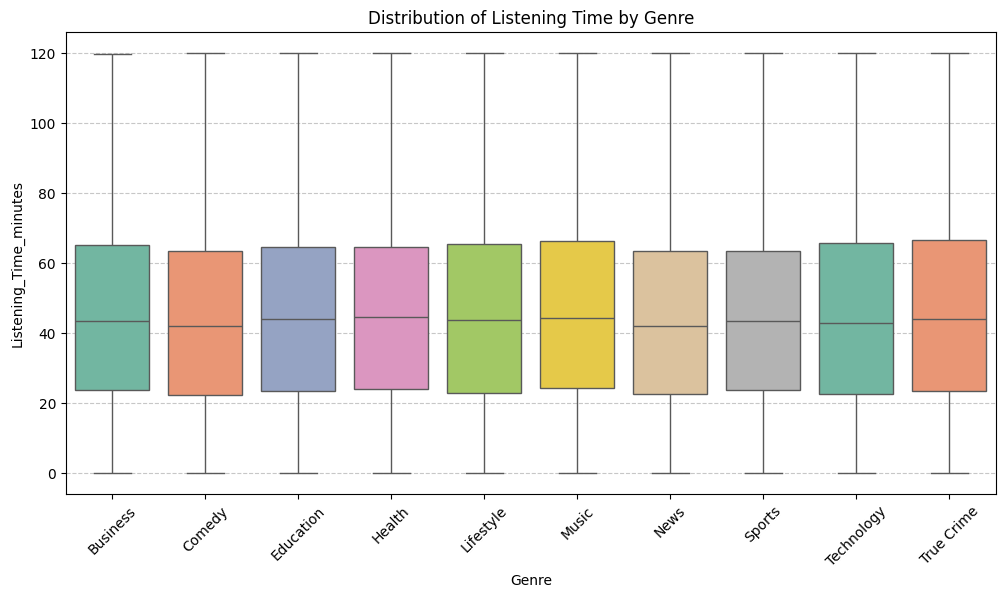

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Genre', y='Listening_Time_minutes', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Distribution of Listening Time by Genre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

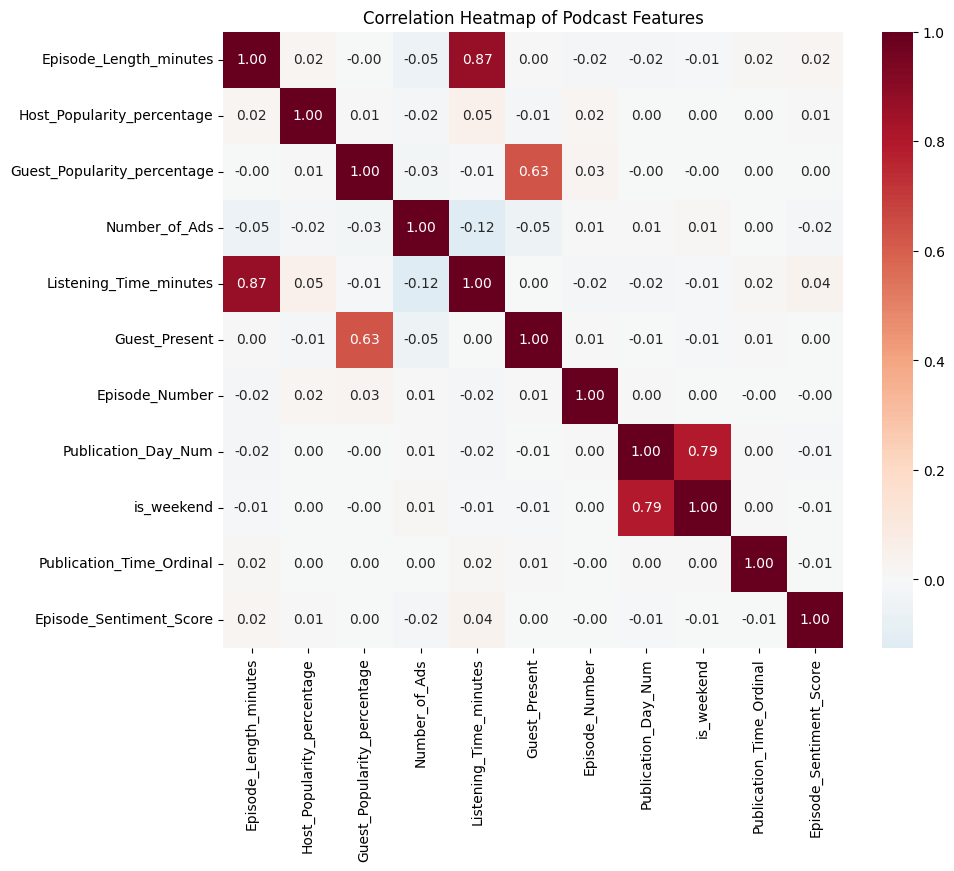

In [37]:
# Only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Podcast Features')
plt.show()

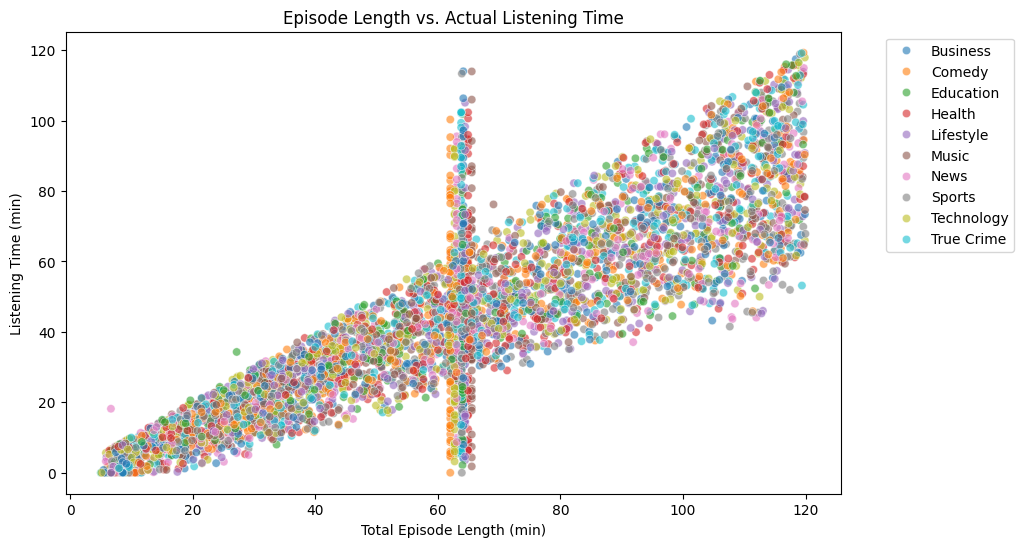

In [38]:
# Sampling to avoid overplotting
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='Episode_Length_minutes', y='Listening_Time_minutes', 
                hue='Genre', alpha=0.6)
plt.title('Episode Length vs. Actual Listening Time')
plt.xlabel('Total Episode Length (min)')
plt.ylabel('Listening Time (min)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

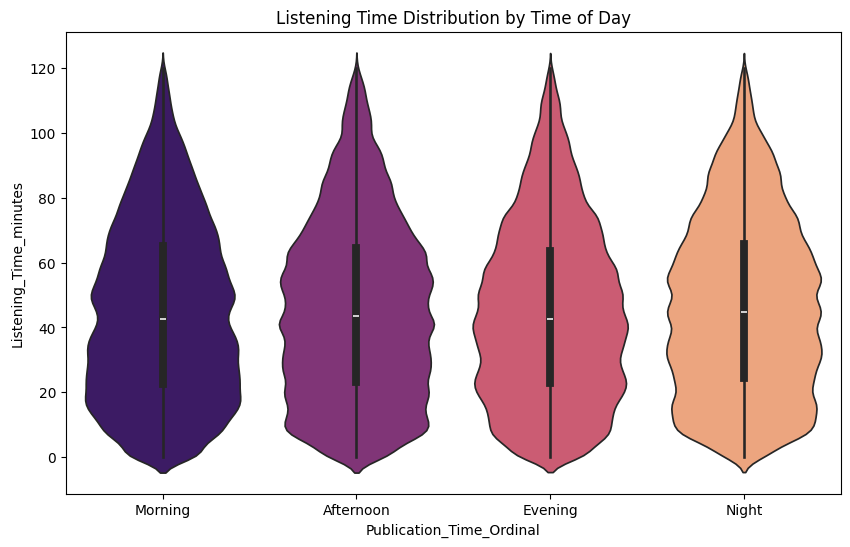

In [39]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Publication_Time_Ordinal', y='Listening_Time_minutes', data=df, palette='magma')
plt.title('Listening Time Distribution by Time of Day')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.show()

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Podcast_Name                 750000 non-null  category
 1   Episode_Length_minutes       750000 non-null  float64 
 2   Genre                        750000 non-null  category
 3   Host_Popularity_percentage   750000 non-null  float64 
 4   Guest_Popularity_percentage  750000 non-null  float64 
 5   Number_of_Ads                750000 non-null  int64   
 6   Listening_Time_minutes       750000 non-null  float64 
 7   Guest_Present                750000 non-null  int64   
 8   Episode_Number               750000 non-null  int64   
 9   Publication_Day_Num          750000 non-null  int64   
 10  is_weekend                   750000 non-null  int64   
 11  Publication_Time_Ordinal     750000 non-null  int64   
 12  Episode_Sentiment_Score      750000 non-null

## Model Development

In [41]:
x = df.drop('Listening_Time_minutes', axis=1)
y = df['Listening_Time_minutes']

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

def algo_test(x, y):
    # Initialize all models
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    # RadiusNeighbors is initialized but not included in the primary list to match your original flow
    rkn = RadiusNeighborsRegressor(radius=1.0)
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb]
    algo_names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree', 
              'Gradient Boosting', 'AdaBoost', 'KNeighborsRegressor', 
              'Decision Tree', 'XGBRegressor']
    
    # Scale features and split data
    x = MinMaxScaler().fit_transform(x)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

    r_squared = []
    rmse = []
    mae = []

    # Create a dataframe to store error and accuracy metrics
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

    # Loop through models to train and predict
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p)**.5)
        mae.append(mean_absolute_error(y_test, p))

    # Populate the result table with calculated metrics
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    # Sort the table by accuracy (R-Squared) and return it
    result_table = result.sort_values('R_Squared', ascending=False)
    return result_table

In [43]:
x=pd.get_dummies(x,drop_first=True)

In [44]:
result= algo_test(x,y)

In [45]:
result

,R_Squared,RMSE,MAE
XGBRegressor,0.769537,13.022316,9.467583
Gradient Boosting,0.765649,13.131715,9.579524
Linear,0.759245,13.309936,9.768449
Ridge,0.759244,13.309941,9.768386
SGD,0.759078,13.314552,9.769495
AdaBoost,0.747249,13.637486,10.112827
Lasso,0.601957,17.114055,13.582268
Decision Tree,0.565992,17.870510,12.103094
Extra Tree,0.550728,18.182041,12.319905
KNeighborsRegressor,0.311034,22.515767,17.965667


In [46]:
 x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)


In [47]:
# Train the winning model specifically
best_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6)
best_model.fit(x_train, y_train)

# Get predictions for final evaluation
y_pred = best_model.predict(x_test)

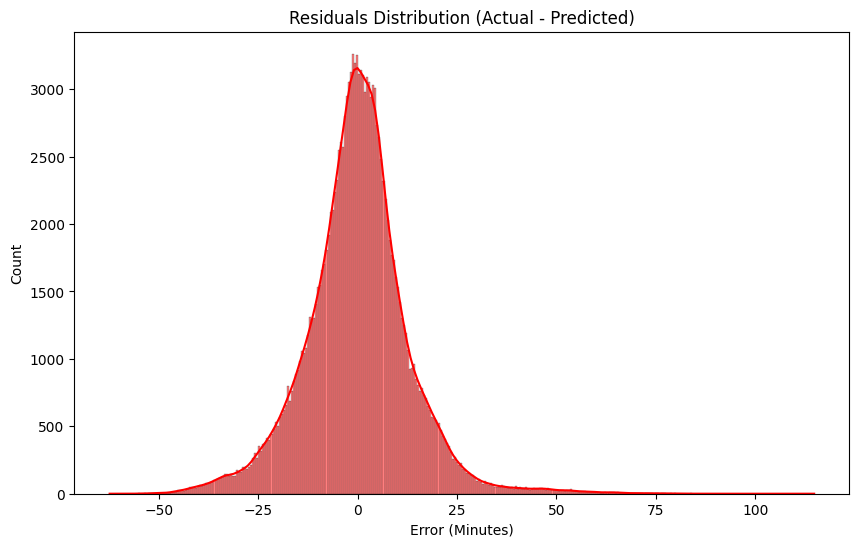

In [48]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='red')
plt.title('Residuals Distribution (Actual - Predicted)')
plt.xlabel('Error (Minutes)')
plt.show()

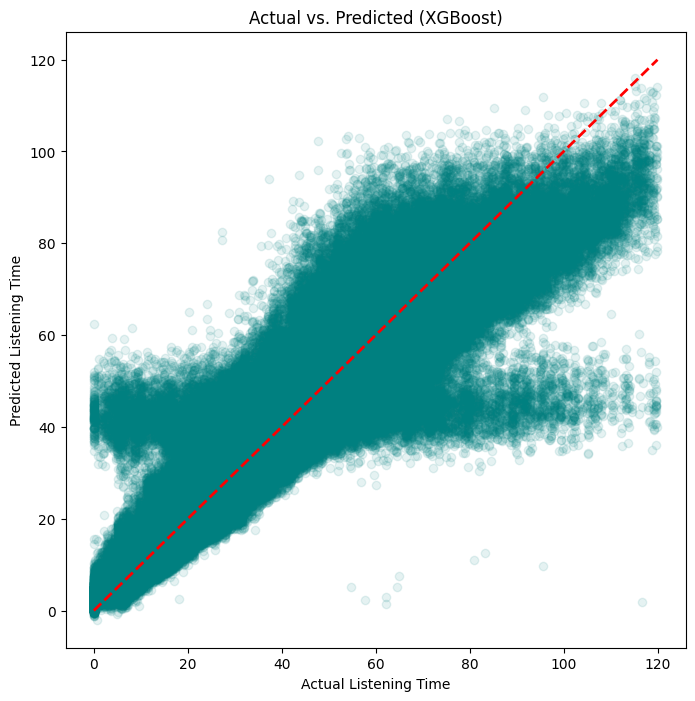

In [49]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.1, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Listening Time')
plt.ylabel('Predicted Listening Time')
plt.title('Actual vs. Predicted (XGBoost)')
plt.show()

In [50]:
import joblib
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x)

# 1. Save the XGBoost Model
joblib.dump(best_model, 'xgb_podcast_model.pkl')

# 2. Save the Scaler (Crucial!)
# Make sure you have the scaler object from your training step
joblib.dump(scaler, 'minmax_scaler.pkl') 

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [51]:
# Save the list of feature names so the app knows the correct column order
joblib.dump(x.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

In [52]:
from IPython.display import FileLink

display(FileLink('xgb_podcast_model.pkl'))
display(FileLink('minmax_scaler.pkl'))
display(FileLink('feature_names.pkl'))

/kaggle/working/xgb_podcast_model.pkl

/kaggle/working/minmax_scaler.pkl

/kaggle/working/feature_names.pkl

## Kaggle Competition Submission

In [53]:
# 1. Identify and assign your model
# If you just ran algo_test, your best model might be 'best_model'
# Adjust the name below to match what you named your XGBoost regressor
try:
    xgb = best_model 
except NameError:
    # If 'best_model' isn't defined, we'll try to pull it from your list if you saved it
    print("Please ensure you have assigned your trained XGBoost model to the variable 'xgb'.")

# 2. Define the Cleaning Function (Podcast specific)
def clean_podcast_data(df_input):
    df = df_input.copy()
    sentiment_map = {'Negative': 1, 'Neutral': 2, 'Positive': 3}
    time_order = {'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}
    
    df['Episode_Sentiment_Score'] = df['Episode_Sentiment'].map(sentiment_map).fillna(2)
    df['Publication_Time_Ordinal'] = df['Publication_Time'].map(time_order).fillna(2)
    df['is_weekend'] = df['Publication_Day'].isin(['Saturday', 'Sunday']).astype(int)
    return df

# 3. Process and Align
test_processed = clean_podcast_data(test)
test_encoded = pd.get_dummies(test_processed.drop(['id', 'Episode_Title'], axis=1, errors='ignore'), drop_first=True)
X_test = test_encoded.reindex(columns=x.columns, fill_value=0)

# 4. Predict
# If 'xgb' is defined, this will now work
test_preds = xgb.predict(X_test)

# 5. Create Submission
submission = pd.DataFrame({
    'id': test['id'],
    'Listening_Time_minutes': test_preds
})

submission['Listening_Time_minutes'] = submission['Listening_Time_minutes'].clip(lower=0)
submission.to_csv("submission.csv", index=False)

print("Submission file successfully created!")

Submission file successfully created!


In [54]:
from IPython.display import FileLink

display(FileLink('submission.csv'))

/kaggle/working/submission.csv